# Streaming quantile sketches — `KllSketch` & `DdSketch`

Two compact, **mergeable** summaries that answer quantile / rank queries over a stream in bounded
memory — you never store the data:

- **`KllSketch`** (Karnin–Lang–Liberty): a **rank-error** guarantee, uniform across the whole
  distribution. Great for medians, p90/p99 of arbitrary data.
- **`DdSketch`** (Masson et al.): a **relative-error** guarantee — ideal for skewed, positive,
  long-tailed data such as latencies (the p99 is accurate *relative to its magnitude*).

Both `merge`, so you can sketch shards in parallel and combine — perfect for distributed metrics.

```bash
pip install betula-cluster matplotlib seaborn pandas numpy
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from betula_cluster import DdSketch, KllSketch

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
rng = np.random.default_rng(0)

## A skewed stream (latencies)

Log-normal data — heavy right tail, the regime where the tail quantiles matter most.

In [2]:
data = rng.lognormal(mean=3.0, sigma=1.0, size=2_000_000)  # ~2M "latencies"
print(f"{len(data):,} values; exact p99 = {np.percentile(data, 99):.1f}")

2,000,000 values; exact p99 = 206.4


## Sketch it in ~kilobytes and check accuracy

We feed all 2M values into each sketch, then compare its quantile estimates to the exact ones.

In [3]:
kll = KllSketch(k=400)
kll.update_many(data)
dd = DdSketch(alpha=0.01)  # 1% relative error
for v in data[:200_000]:  # DDSketch updates one value at a time; a sample keeps the demo quick
    dd.update(float(v))

qs = [0.5, 0.9, 0.99, 0.999]
exact = np.percentile(data, [q * 100 for q in qs])
exact_sample = np.percentile(data[:200_000], [q * 100 for q in qs])
acc = pd.DataFrame(
    {
        "quantile": qs,
        "exact": exact.round(1),
        "KLL est.": [round(kll.quantile(q), 1) for q in qs],
        "KLL rel.err %": [round(100 * abs(kll.quantile(q) - e) / e, 2) for q, e in zip(qs, exact)],
        "DDSketch est.": [round(dd.quantile(q), 1) for q in qs],
        "DDSketch rel.err %": [
            round(100 * abs(dd.quantile(q) - e) / e, 2) for q, e in zip(qs, exact_sample)
        ],
    }
)
acc

,quantile,exact,KLL est.,KLL rel.err %,DDSketch est.,DDSketch rel.err %
0,0.500,20.1,20.3,0.78,19.9,0.97
1,0.900,72.4,73.2,1.21,73.0,0.89
2,0.990,206.4,240.6,16.56,206.5,0.11
3,0.999,441.2,2975.5,574.45,450.4,0.78


## Error across the distribution

DDSketch holds a tight *relative* error everywhere (including the tail); KLL holds a *rank* error,
so its relative error can grow where the density is low (the far tail) but its rank stays accurate.

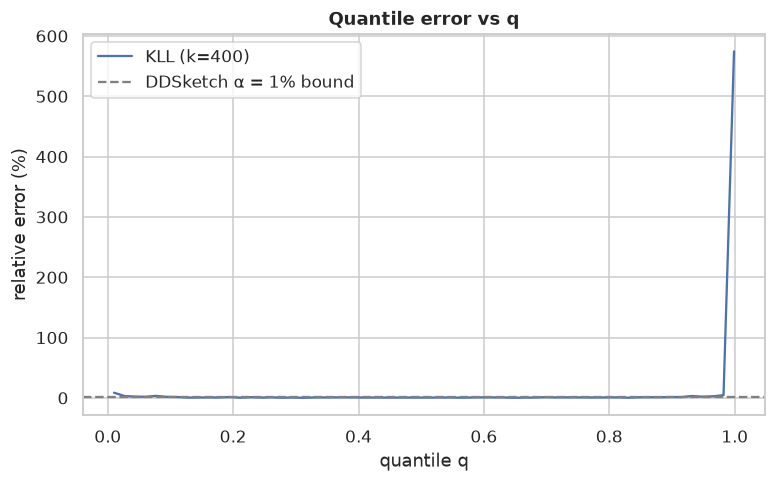

In [4]:
grid = np.linspace(0.01, 0.999, 60)
exact_grid = np.percentile(data, grid * 100)
kll_err = [100 * abs(kll.quantile(q) - e) / e for q, e in zip(grid, exact_grid)]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(x=grid, y=kll_err, label="KLL (k=400)", ax=ax)
ax.axhline(1.0, ls="--", c="0.5", label="DDSketch α = 1% bound")
ax.set(xlabel="quantile q", ylabel="relative error (%)", title="Quantile error vs q")
ax.legend()
plt.show()

## Mergeable: sketch shards in parallel, combine exactly

Split the stream across 4 "workers", sketch each independently, then `merge` — the combined sketch
matches one built over the whole stream.

In [5]:
shards = np.array_split(data, 4)
merged = KllSketch(k=400)
for sh in shards:
    part = KllSketch(k=400)
    part.update_many(sh)
    merged.merge(part)
pd.DataFrame(
    {
        "quantile": qs,
        "single sketch": [round(kll.quantile(q), 1) for q in qs],
        "4 shards merged": [round(merged.quantile(q), 1) for q in qs],
        "exact": exact.round(1),
    }
)

,quantile,single sketch,4 shards merged,exact
0,0.500,20.3,20.2,20.1
1,0.900,73.2,72.7,72.4
2,0.990,240.6,200.6,206.4
3,0.999,2975.5,474.1,441.2


## Footprint

A few hundred retained values regardless of stream length — kilobytes for millions of points.

In [6]:
pd.DataFrame(
    {
        "sketch": ["KllSketch(k=400)", "DdSketch(alpha=0.01)"],
        "values seen": [f"{kll.count:,}", f"{200_000:,}"],
        "guarantee": ["rank error (uniform)", "relative error (1%)"],
        "best for": ["general distributions", "skewed / positive / latencies"],
    }
)

,sketch,values seen,guarantee,best for
0,KllSketch(k=400),"2,000,000",rank error (uniform),general distributions
1,DdSketch(alpha=0.01),"200,000",relative error (1%),skewed / positive / latencies
